# Micro-Expression Spotting (POC-ABS)
Onset–Apex–Offset detection based on POC-ABS magnitude signals

### Pipeline (step-by-step, RAM-friendly)
1. **Step 1** — Extract frames from q1–q5 videos → save to disk
2. **Step 2** — Load frame pairs → face detection → ROI → POC-ABS magnitude → save `.npy`
3. **Step 3** — Load magnitudes → smooth → top-3 peaks → onset/offset → plot

In [1]:
import cv2
import dlib
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import re
import gc
from scipy.signal import savgol_filter, find_peaks

PROJECT_ROOT = os.path.abspath(".")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from features_extraction.poc import POC
from features_extraction.vektor import Vektor
from features_extraction.quadran import Quadran

In [24]:
# ======================================================
# CONFIGURATION
# ======================================================
ROOT_DIR = "./dataset"
OUTPUT_DIR = "./output"
FRAMES_DIR = os.path.join(OUTPUT_DIR, "frames")
MAGNITUDES_DIR = os.path.join(OUTPUT_DIR, "magnitudes")
PLOTS_DIR = os.path.join(OUTPUT_DIR, "plots")
PREDICTOR_PATH = "preprocess-anxiety/models/shape_predictor_68_face_landmarks.dat"

BLOCK_SIZE = 7

# Smoothing
SAVGOL_WINDOW = 28
SAVGOL_POLYORDER = 3

# Peak detection
MAX_PEAKS = 3

# Onset-offset detection
CUTOFF_RATIO = 0.20

# ROI definitions (dlib 68-landmark indices)
REGIONS = {
    "mata_kanan":  list(range(42, 48)),
    "mata_kiri":   list(range(36, 42)),
    "alis_kanan":  list(range(22, 27)),
    "alis_kiri":   list(range(17, 22)),
    "mulut":       list(range(48, 68)),
}

TARGET_SIZE = {
    "mata_kanan":  (48, 32),
    "mata_kiri":   (48, 32),
    "alis_kanan":  (48, 20),
    "alis_kiri":   (48, 20),
    "mulut":       (70, 35),
}

PADDING_X = 6
PADDING_Y = 8

def natural_sort_key(s):
    return [int(t) if t.isdigit() else t.lower()
            for t in re.split(r'(\d+)', s)]

# Create output dirs
for d in [FRAMES_DIR, MAGNITUDES_DIR, PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)

print("✅ Configuration ready")

✅ Configuration ready


## Step 1: Extract Frames from Videos
Read all q1–q5 `.avi` files per subject, concatenate frames, save as `.jpg` to disk.

In [3]:
# ======================================================
# STEP 1: EXTRACT FRAMES → SAVE TO DISK
# ======================================================

subject_count = 0

for label in sorted(os.listdir(ROOT_DIR)):
    label_path = os.path.join(ROOT_DIR, label)
    if not os.path.isdir(label_path):
        continue

    for subject_name in sorted(os.listdir(label_path), key=natural_sort_key):
        subject_path = os.path.join(label_path, subject_name)
        if not os.path.isdir(subject_path):
            continue

        output_name = f"{label}_{subject_name}"
        frames_out = os.path.join(FRAMES_DIR, output_name)

        # Skip if already extracted
        if os.path.isdir(frames_out) and len(os.listdir(frames_out)) > 0:
            print(f"⏩ Skip {output_name}: frames already extracted")
            subject_count += 1
            continue

        os.makedirs(frames_out, exist_ok=True)

        # Collect q1-q5 folders sorted naturally
        q_dirs = sorted(
            [d for d in os.listdir(subject_path) if os.path.isdir(os.path.join(subject_path, d))],
            key=natural_sort_key
        )

        frame_idx = 0
        for q_dir in q_dirs:
            q_path = os.path.join(subject_path, q_dir)
            avi_files = sorted(
                [f for f in os.listdir(q_path) if f.lower().endswith(".avi")],
                key=natural_sort_key
            )
            for avi in avi_files:
                cap = cv2.VideoCapture(os.path.join(q_path, avi))
                while True:
                    ret, frame = cap.read()
                    if not ret:
                        break
                    fname = os.path.join(frames_out, f"frame_{frame_idx:05d}.jpg")
                    cv2.imwrite(fname, frame)
                    frame_idx += 1
                cap.release()

        print(f"✅ {output_name}: {frame_idx} frames saved")
        subject_count += 1
        gc.collect()

print(f"\n🎉 Step 1 done! {subject_count} subject(s). Frames in {FRAMES_DIR}/")

✅ anxiety-rendah_ahmad_rifqi_hendriansyah_1765181629492: 1853 frames saved
✅ anxiety-rendah_akhmad_aakhif_athallah_1765186538689: 2896 frames saved
✅ anxiety-rendah_haikal_muhammad_rafli_1765172380087: 2448 frames saved
✅ anxiety-rendah_hizkia_elsadanta_1765271523167: 2132 frames saved
✅ anxiety-rendah_key_firdausi_alfarel_1765179452414: 2612 frames saved
✅ anxiety-tinggi_aaisyah_nursalsabiil_ni_patriarti_1765168488512: 2943 frames saved
✅ anxiety-tinggi_achmad_anfasa_rabbany_1765271116146: 1999 frames saved
✅ anxiety-tinggi_dika_arie_arrifky_1765264792036: 2823 frames saved
✅ anxiety-tinggi_fabian_ananda_merdana_1765255189409: 2983 frames saved
✅ anxiety-tinggi_muhammad_khalid_atthoriq_1765181327851: 1870 frames saved
✅ anxiety-tinggi_nova_eliza_maharani_1765181769652: 2742 frames saved

🎉 Step 1 done! 11 subject(s). Frames in ./output/frames/


## Step 2: Compute POC-ABS Magnitudes
Load frame pairs (2 at a time), detect face, extract 5 ROIs, compute POC-ABS magnitude, save as `.npy`.

In [4]:
# ======================================================
# STEP 2: COMPUTE MAGNITUDES → SAVE .npy
# ======================================================

# Load dlib models
if not os.path.exists(PREDICTOR_PATH):
    raise FileNotFoundError(f"Predictor tidak ditemukan: {PREDICTOR_PATH}")

detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor(PREDICTOR_PATH)
print("✅ Dlib models loaded")


def extract_region(image, landmarks, indices):
    pts = [(landmarks.part(i).x, landmarks.part(i).y) for i in indices]
    xs, ys = zip(*pts)
    left   = max(0, min(xs) - PADDING_X)
    top    = max(0, min(ys) - PADDING_Y)
    right  = min(image.shape[1], max(xs) + PADDING_X)
    bottom = min(image.shape[0], max(ys) + PADDING_Y)
    return image[top:bottom, left:right]


def detect_landmarks(gray):
    """Detect face and return landmarks, or None if no face."""
    faces = detector(gray)
    if len(faces) > 0:
        return predictor(gray, faces[0])
    return None


def compute_frame_magnitude(prev_gray, prev_lm, curr_gray, curr_lm):
    """Compute avg POC-ABS magnitude across all ROIs for one frame pair."""
    roi_mags = []
    for region_name, lm_indices in REGIONS.items():
        try:
            roi_prev = extract_region(prev_gray, prev_lm, lm_indices)
            roi_curr = extract_region(curr_gray, curr_lm, lm_indices)

            if roi_prev.size == 0 or roi_curr.size == 0:
                return 0.0

            target = TARGET_SIZE[region_name]
            roi_prev = cv2.resize(roi_prev, target)
            roi_curr = cv2.resize(roi_curr, target)

            poc = POC(roi_prev, roi_curr, BLOCK_SIZE)
            vec = Vektor(poc.getPOC(), BLOCK_SIZE)
            quad_data = Quadran(vec.getVektor()).getQuadran()

            magnitudes = [float(block[4]) for block in quad_data]
            roi_mags.append(np.mean(magnitudes) if magnitudes else 0.0)
        except Exception:
            return 0.0

    return np.mean(roi_mags) if roi_mags else 0.0


# --- Process each subject ---
subject_count = 0

for subject_folder in sorted(os.listdir(FRAMES_DIR), key=natural_sort_key):
    subject_frames_dir = os.path.join(FRAMES_DIR, subject_folder)
    if not os.path.isdir(subject_frames_dir):
        continue

    npy_path = os.path.join(MAGNITUDES_DIR, f"{subject_folder}.npy")

    # Skip if already computed
    if os.path.exists(npy_path):
        print(f"⏩ Skip {subject_folder}: magnitudes already computed")
        subject_count += 1
        continue

    # Get sorted frame file list
    frame_files = sorted(
        [f for f in os.listdir(subject_frames_dir) if f.endswith(".jpg")],
        key=natural_sort_key
    )

    if len(frame_files) < 3:
        print(f"⚠️  Skip {subject_folder}: too few frames ({len(frame_files)})")
        continue

    print(f"🔄 Processing {subject_folder} ({len(frame_files)} frames)...")

    magnitude_list = []

    # Load first frame
    prev_gray = cv2.imread(os.path.join(subject_frames_dir, frame_files[0]), cv2.IMREAD_GRAYSCALE)
    prev_lm = detect_landmarks(prev_gray)

    for i in range(1, len(frame_files)):
        curr_gray = cv2.imread(os.path.join(subject_frames_dir, frame_files[i]), cv2.IMREAD_GRAYSCALE)
        curr_lm = detect_landmarks(curr_gray)

        if prev_lm is not None and curr_lm is not None:
            mag = compute_frame_magnitude(prev_gray, prev_lm, curr_gray, curr_lm)
        else:
            mag = 0.0

        magnitude_list.append(mag)

        prev_gray = curr_gray
        prev_lm = curr_lm

    # Save
    np.save(npy_path, np.array(magnitude_list, dtype=float))
    print(f"✅ {subject_folder}: {len(magnitude_list)} magnitudes → {npy_path}")
    subject_count += 1
    gc.collect()

print(f"\n🎉 Step 2 done! {subject_count} subject(s). Magnitudes in {MAGNITUDES_DIR}/")

✅ Dlib models loaded
🔄 Processing anxiety-rendah_ahmad_rifqi_hendriansyah_1765181629492 (1853 frames)...
✅ anxiety-rendah_ahmad_rifqi_hendriansyah_1765181629492: 1852 magnitudes → ./output/magnitudes/anxiety-rendah_ahmad_rifqi_hendriansyah_1765181629492.npy
🔄 Processing anxiety-rendah_akhmad_aakhif_athallah_1765186538689 (2896 frames)...
✅ anxiety-rendah_akhmad_aakhif_athallah_1765186538689: 2895 magnitudes → ./output/magnitudes/anxiety-rendah_akhmad_aakhif_athallah_1765186538689.npy
🔄 Processing anxiety-rendah_haikal_muhammad_rafli_1765172380087 (2448 frames)...
✅ anxiety-rendah_haikal_muhammad_rafli_1765172380087: 2447 magnitudes → ./output/magnitudes/anxiety-rendah_haikal_muhammad_rafli_1765172380087.npy
🔄 Processing anxiety-rendah_hizkia_elsadanta_1765271523167 (2132 frames)...
✅ anxiety-rendah_hizkia_elsadanta_1765271523167: 2131 magnitudes → ./output/magnitudes/anxiety-rendah_hizkia_elsadanta_1765271523167.npy
🔄 Processing anxiety-rendah_key_firdausi_alfarel_1765179452414 (2612 f

## Step 3: Visualize (Onset–Apex–Offset)
Load `.npy` magnitudes, smooth, detect top-3 peaks, find onset/offset, plot with frame numbers.

Plotting anxiety-rendah_ahmad_rifqi_hendriansyah_1765181629492...
Apex: 0.5312 | Min: 0.2016 | Threshold: 0.2675
Apex: 0.6423 | Min: 0.2016 | Threshold: 0.2897
Apex: 0.4875 | Min: 0.2016 | Threshold: 0.2588


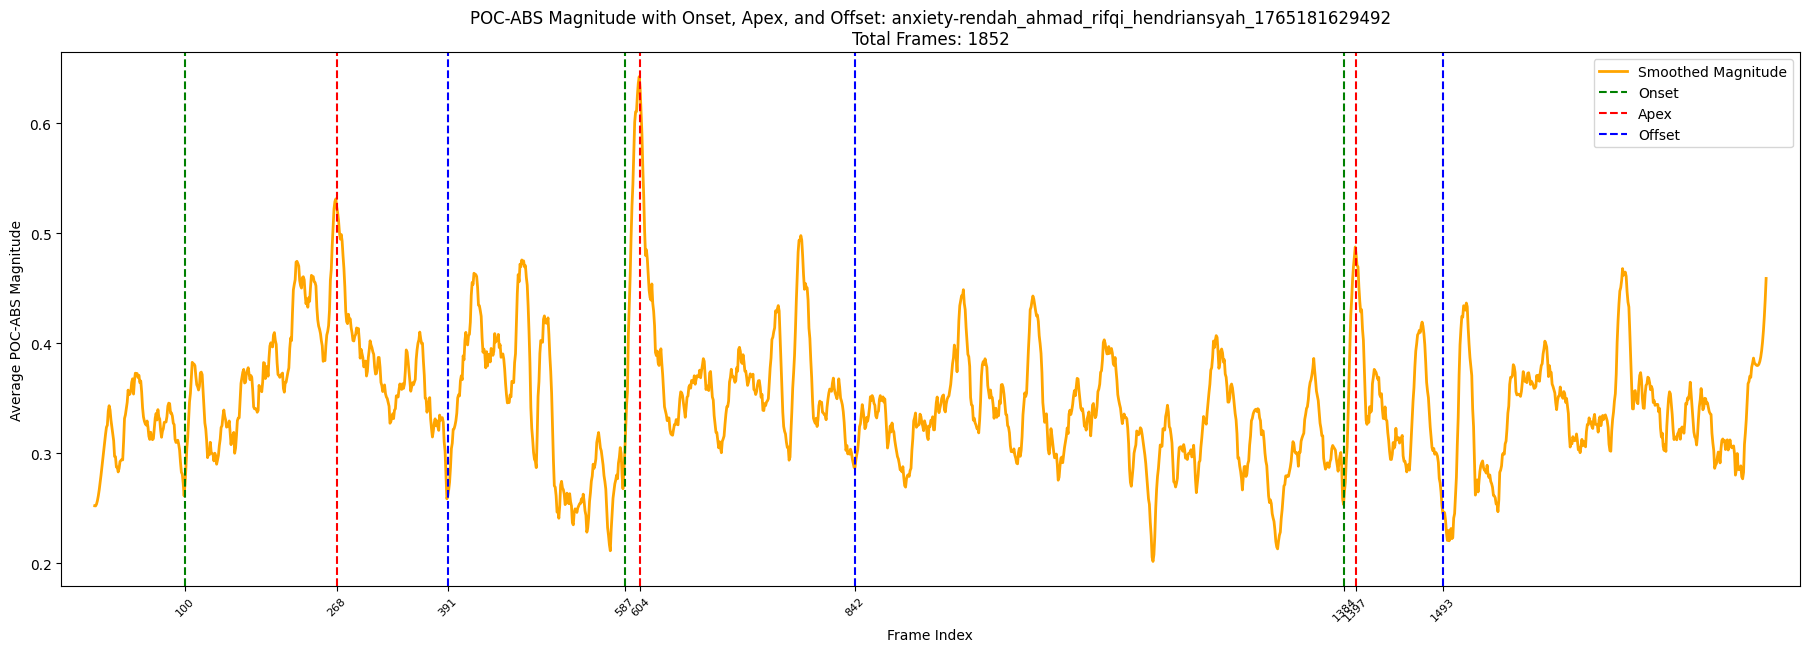

anxiety-rendah_ahmad_rifqi_hendriansyah_1765181629492: 3 peak(s) → ./output/plots/anxiety-rendah_ahmad_rifqi_hendriansyah_1765181629492.png
Plotting anxiety-rendah_akhmad_aakhif_athallah_1765186538689...
Apex: 0.9837 | Min: 0.6796 | Threshold: 0.7404
Apex: 0.9556 | Min: 0.6796 | Threshold: 0.7348
Apex: 0.9599 | Min: 0.6796 | Threshold: 0.7357


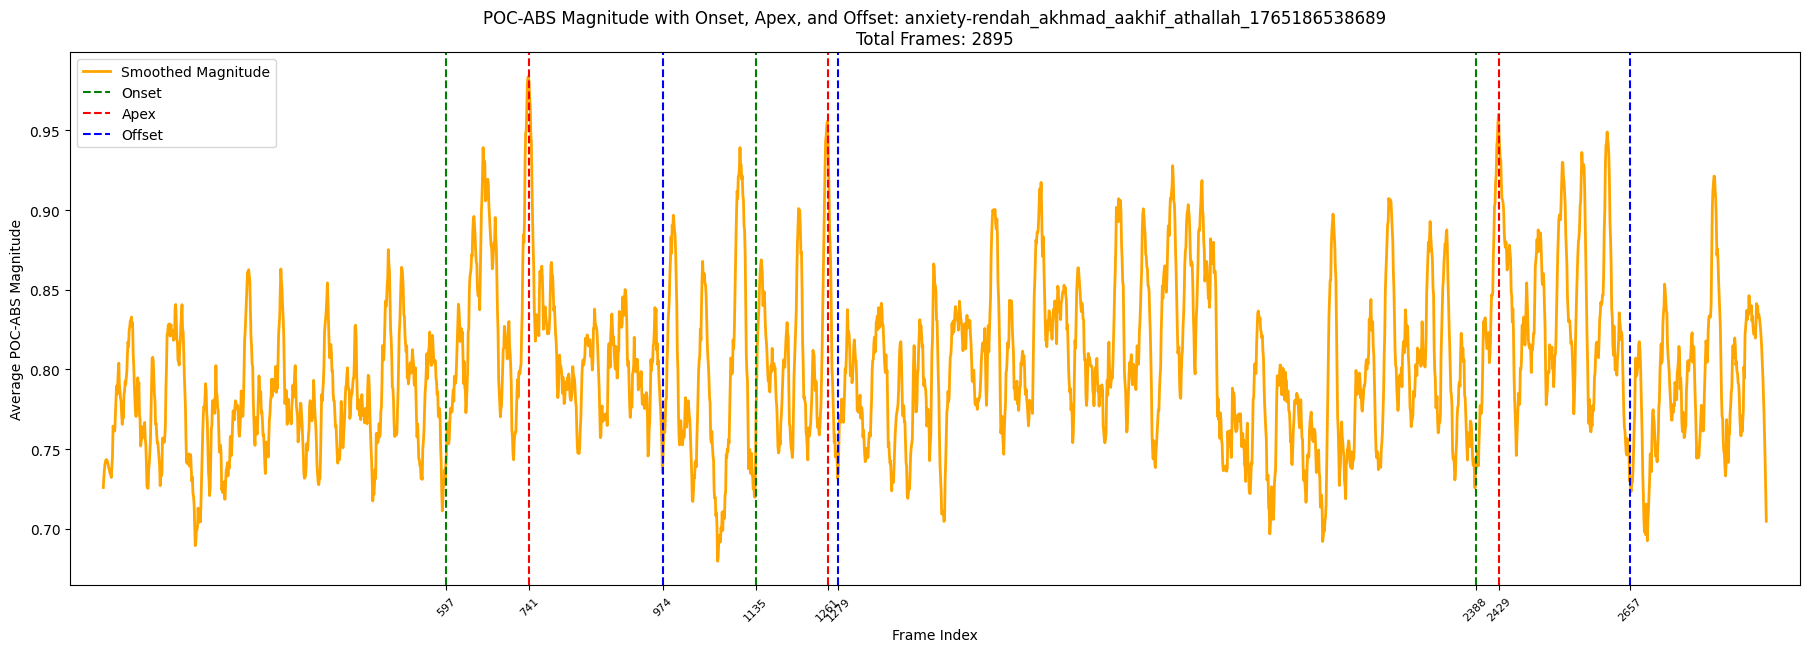

anxiety-rendah_akhmad_aakhif_athallah_1765186538689: 3 peak(s) → ./output/plots/anxiety-rendah_akhmad_aakhif_athallah_1765186538689.png
Plotting anxiety-rendah_haikal_muhammad_rafli_1765172380087...
Apex: 0.4326 | Min: 0.1289 | Threshold: 0.1896
Apex: 0.5255 | Min: 0.1289 | Threshold: 0.2082
Apex: 0.5104 | Min: 0.1289 | Threshold: 0.2052


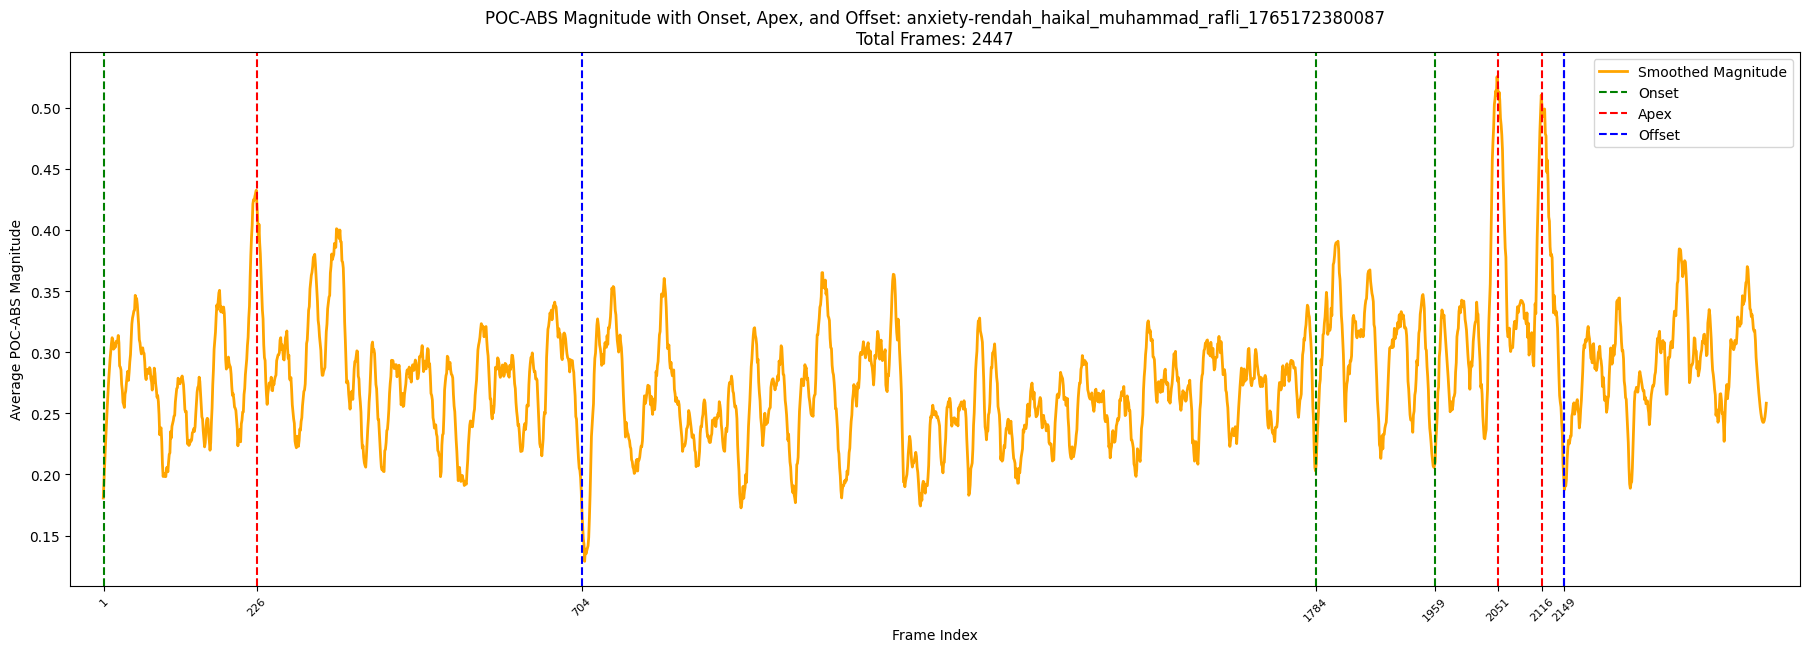

anxiety-rendah_haikal_muhammad_rafli_1765172380087: 3 peak(s) → ./output/plots/anxiety-rendah_haikal_muhammad_rafli_1765172380087.png
Plotting anxiety-rendah_hizkia_elsadanta_1765271523167...
Apex: 0.6597 | Min: 0.3130 | Threshold: 0.3824
Apex: 0.6441 | Min: 0.3130 | Threshold: 0.3793
Apex: 0.5999 | Min: 0.3130 | Threshold: 0.3704


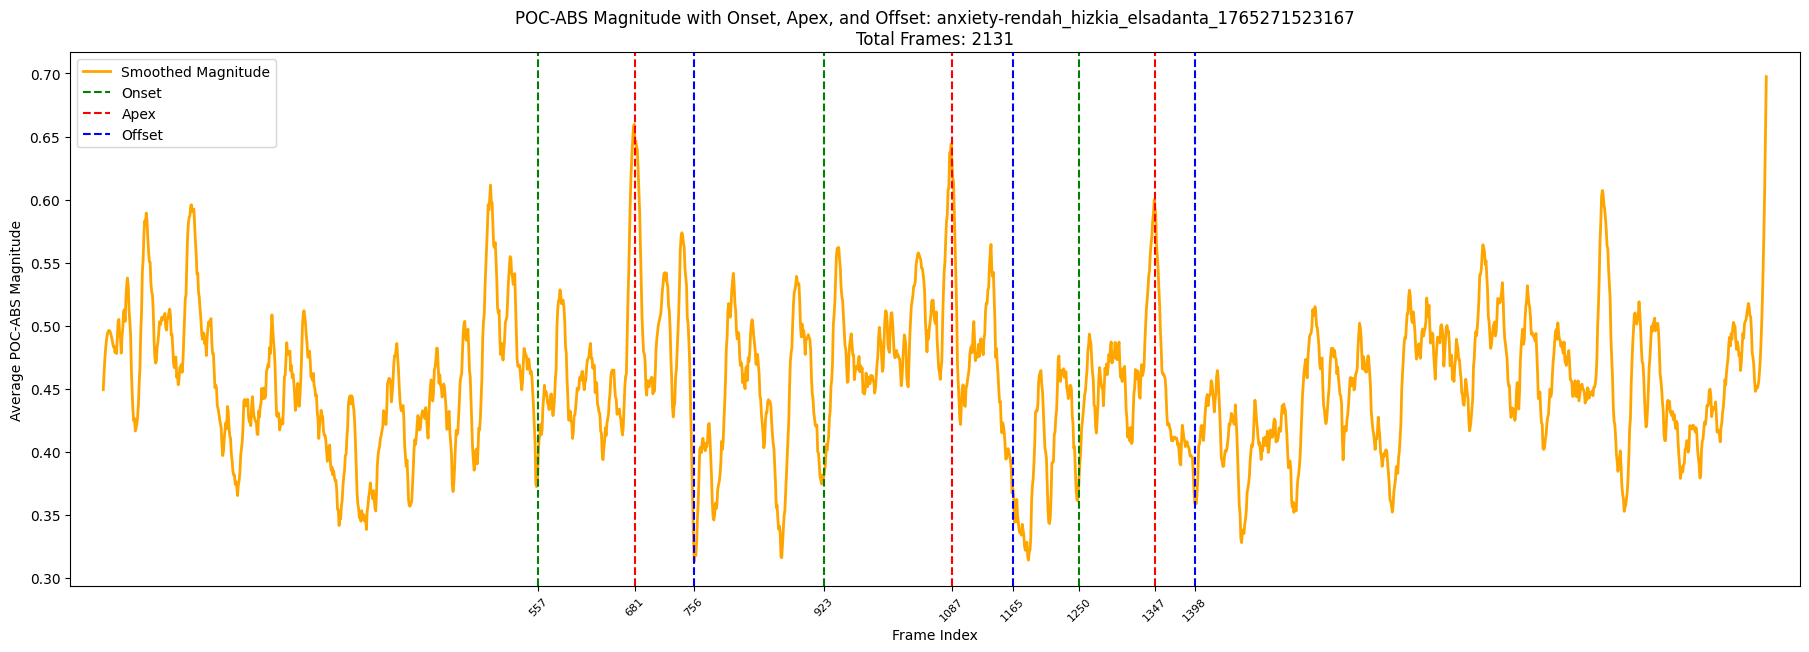

anxiety-rendah_hizkia_elsadanta_1765271523167: 3 peak(s) → ./output/plots/anxiety-rendah_hizkia_elsadanta_1765271523167.png
Plotting anxiety-rendah_key_firdausi_alfarel_1765179452414...
Apex: 0.5007 | Min: 0.2088 | Threshold: 0.2672
Apex: 0.4823 | Min: 0.2088 | Threshold: 0.2635
Apex: 0.4990 | Min: 0.2088 | Threshold: 0.2668


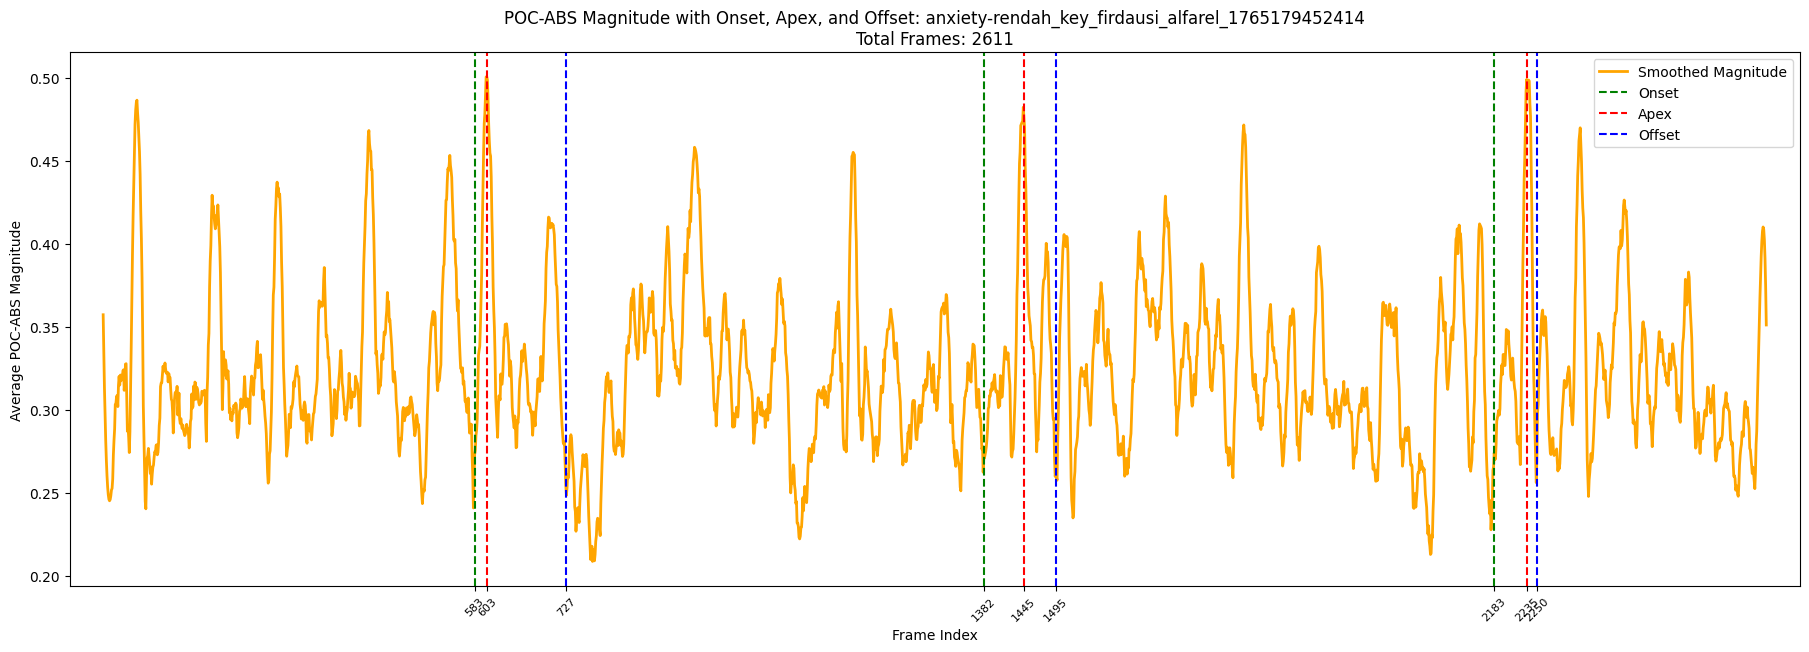

anxiety-rendah_key_firdausi_alfarel_1765179452414: 3 peak(s) → ./output/plots/anxiety-rendah_key_firdausi_alfarel_1765179452414.png
Plotting anxiety-tinggi_aaisyah_nursalsabiil_ni_patriarti_1765168488512...
Apex: 0.2250 | Min: 0.0576 | Threshold: 0.0911
Apex: 0.2541 | Min: 0.0576 | Threshold: 0.0969
Apex: 0.2316 | Min: 0.0576 | Threshold: 0.0924


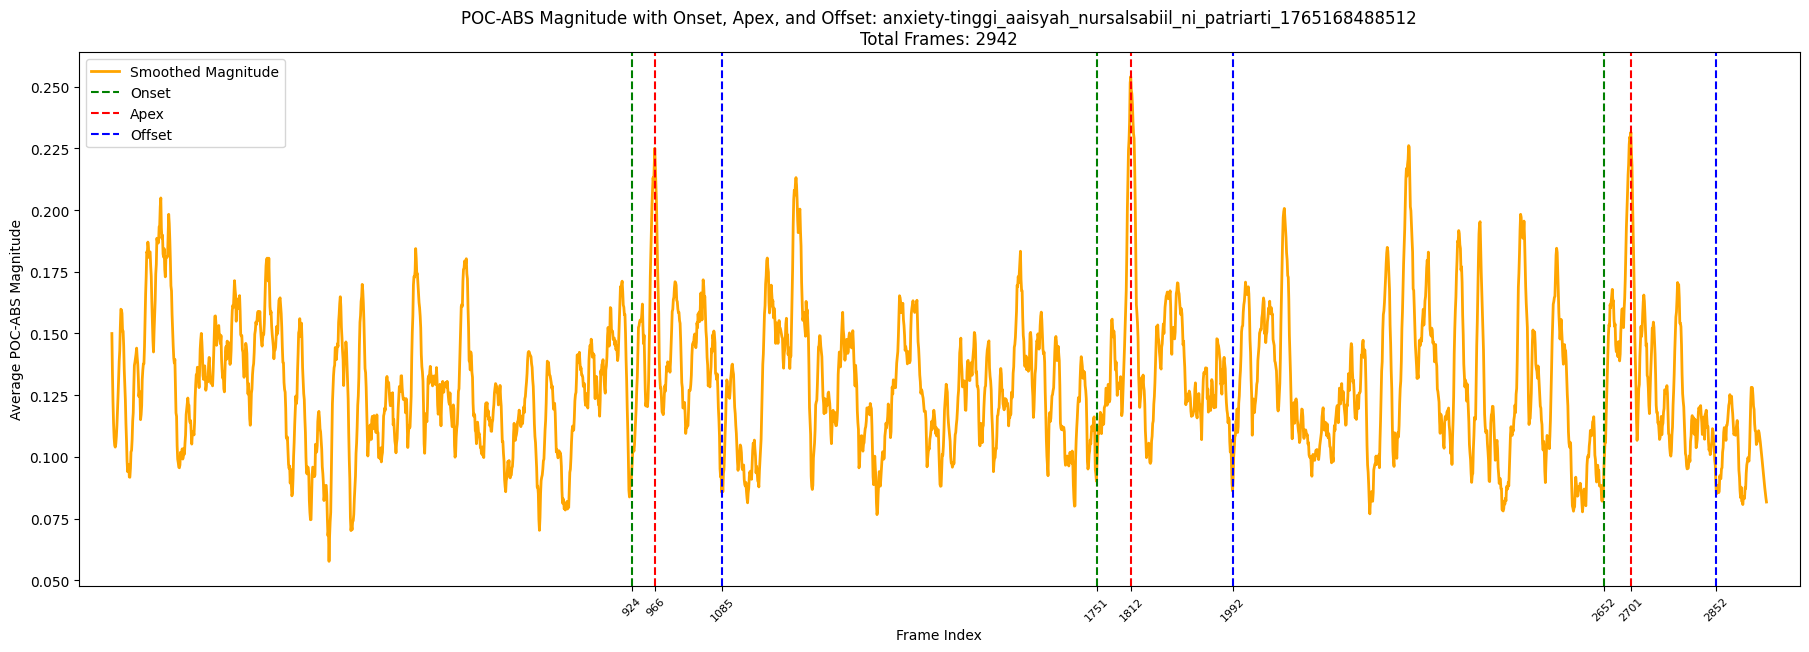

anxiety-tinggi_aaisyah_nursalsabiil_ni_patriarti_1765168488512: 3 peak(s) → ./output/plots/anxiety-tinggi_aaisyah_nursalsabiil_ni_patriarti_1765168488512.png
Plotting anxiety-tinggi_achmad_anfasa_rabbany_1765271116146...
Apex: 0.7302 | Min: 0.4548 | Threshold: 0.5098
Apex: 0.7110 | Min: 0.4548 | Threshold: 0.5060
Apex: 0.7247 | Min: 0.4548 | Threshold: 0.5088


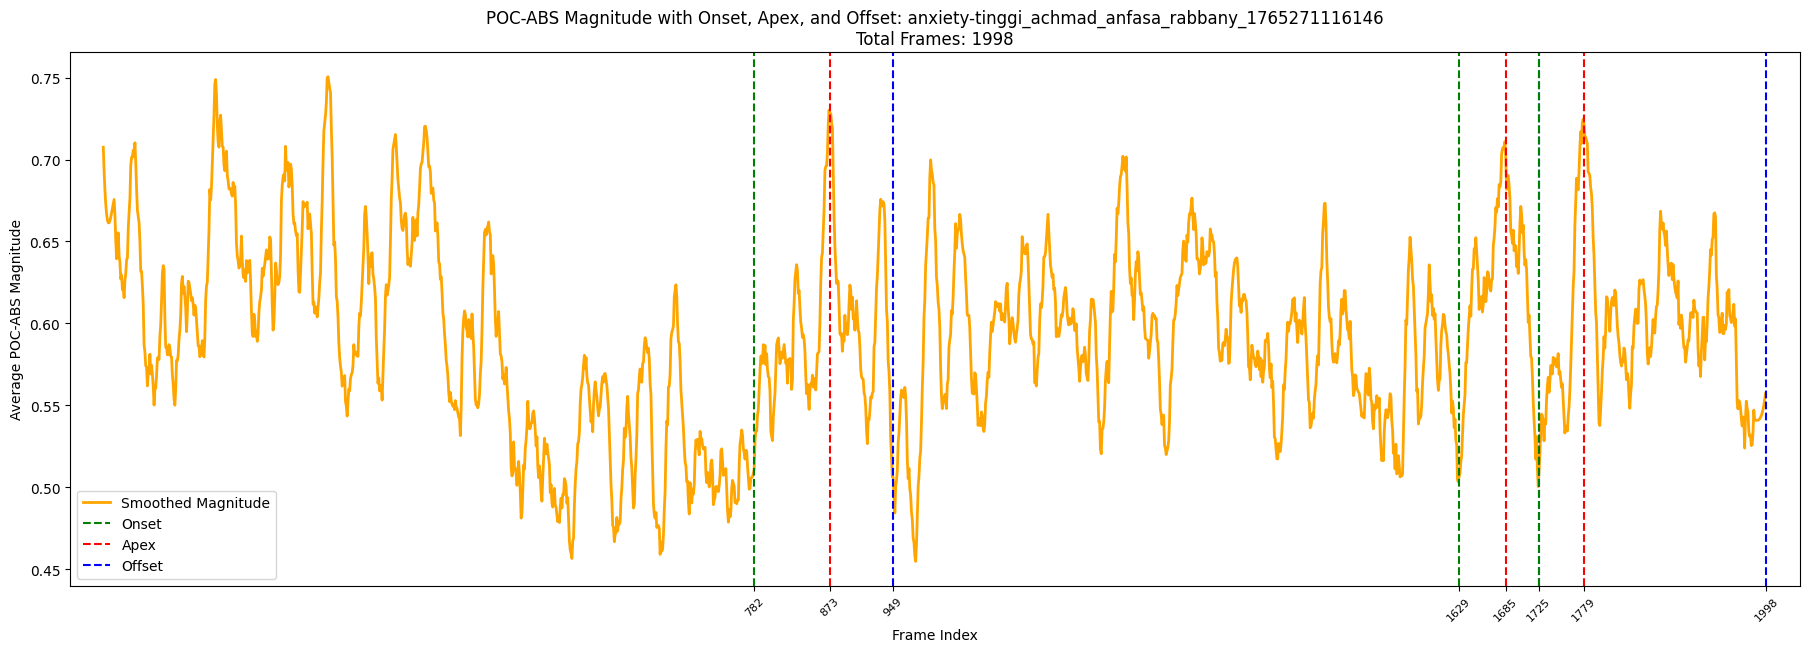

anxiety-tinggi_achmad_anfasa_rabbany_1765271116146: 3 peak(s) → ./output/plots/anxiety-tinggi_achmad_anfasa_rabbany_1765271116146.png
Plotting anxiety-tinggi_dika_arie_arrifky_1765264792036...
Apex: 0.4437 | Min: 0.0967 | Threshold: 0.1661
Apex: 0.4719 | Min: 0.0967 | Threshold: 0.1718
Apex: 0.5038 | Min: 0.0967 | Threshold: 0.1781


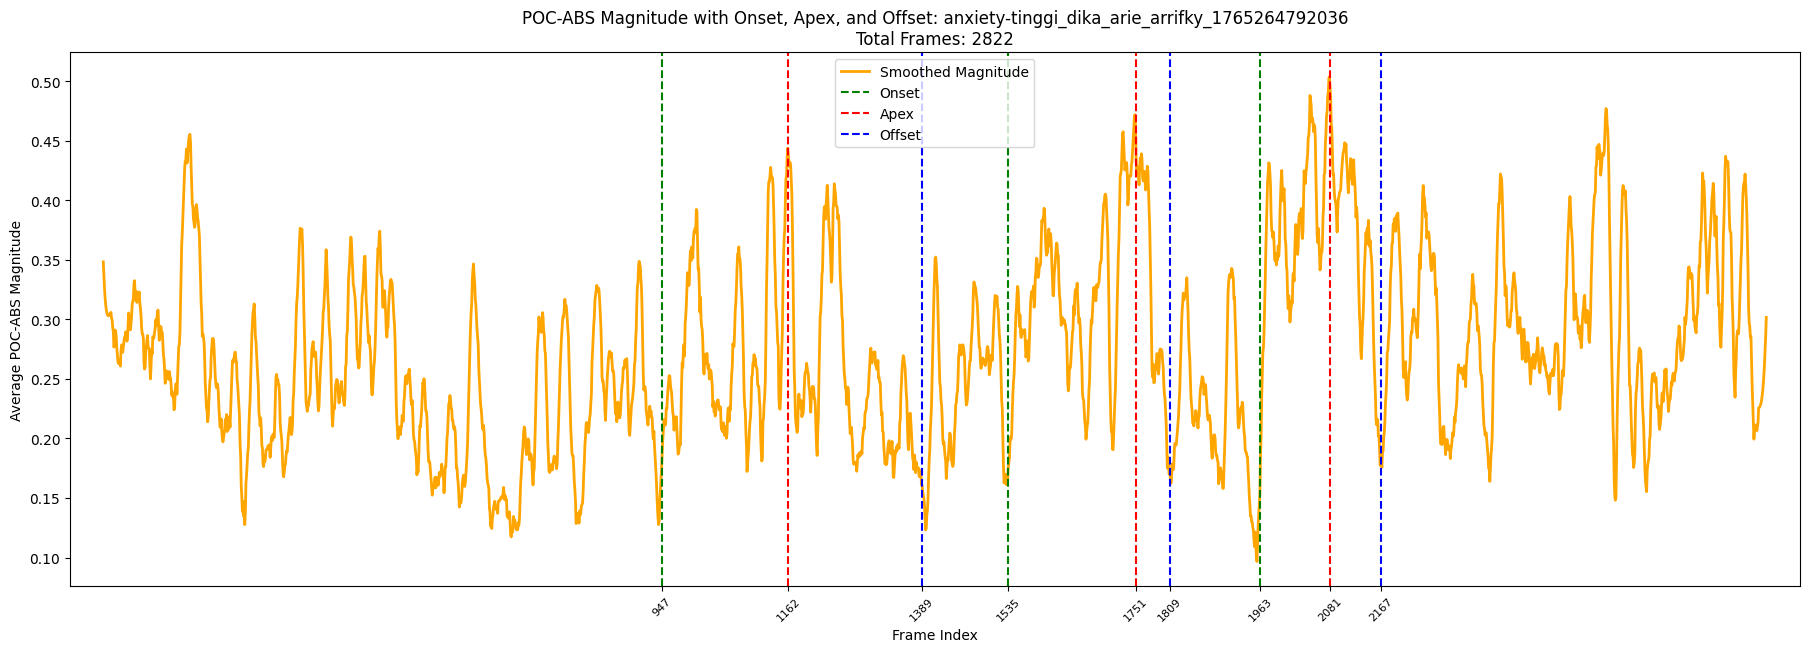

anxiety-tinggi_dika_arie_arrifky_1765264792036: 3 peak(s) → ./output/plots/anxiety-tinggi_dika_arie_arrifky_1765264792036.png
Plotting anxiety-tinggi_fabian_ananda_merdana_1765255189409...
Apex: 0.2858 | Min: 0.0765 | Threshold: 0.1183
Apex: 0.2714 | Min: 0.0765 | Threshold: 0.1155
Apex: 0.3003 | Min: 0.0765 | Threshold: 0.1212


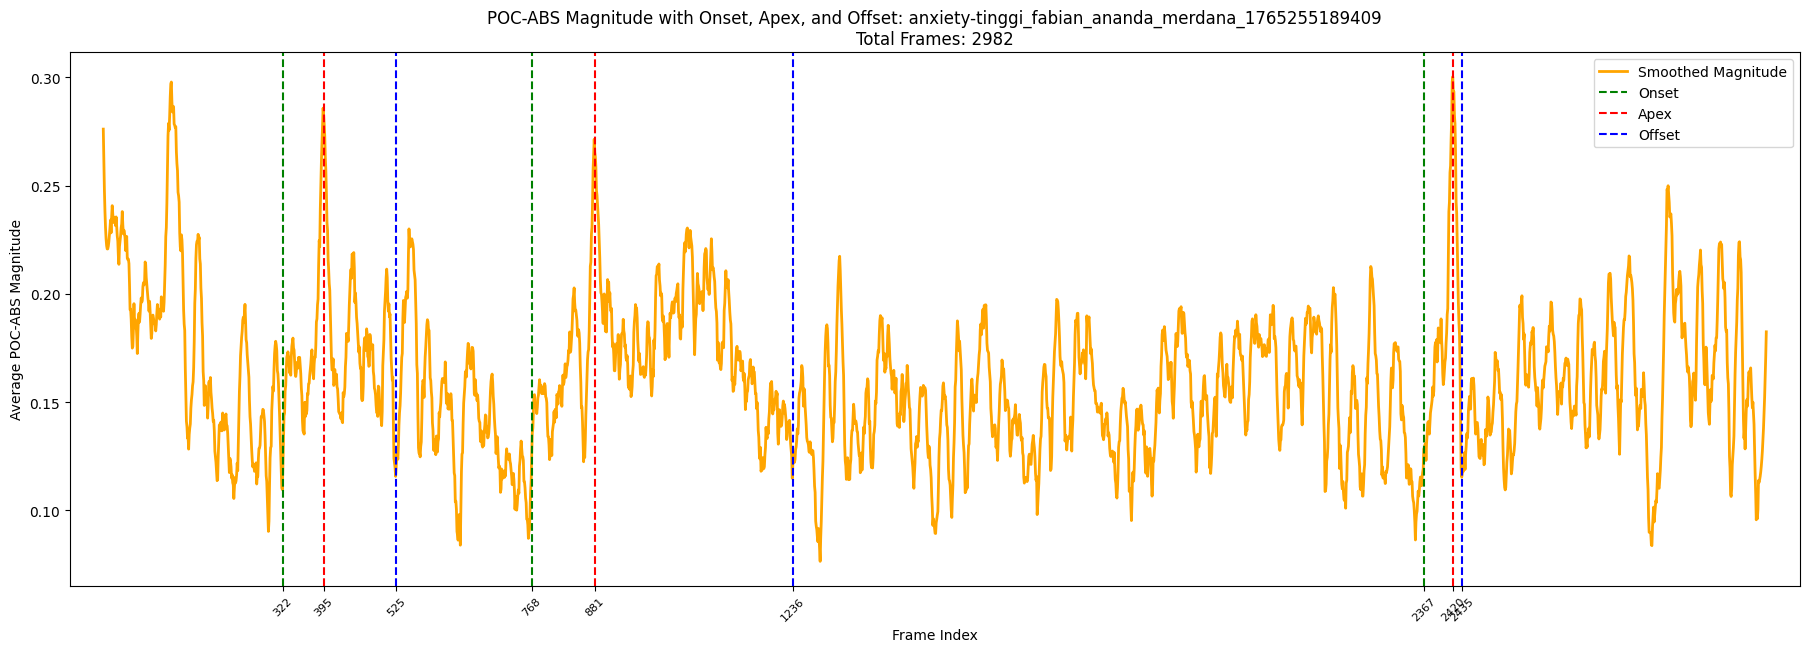

anxiety-tinggi_fabian_ananda_merdana_1765255189409: 3 peak(s) → ./output/plots/anxiety-tinggi_fabian_ananda_merdana_1765255189409.png
Plotting anxiety-tinggi_muhammad_khalid_atthoriq_1765181327851...
Apex: 0.6994 | Min: 0.2967 | Threshold: 0.3773
Apex: 0.6501 | Min: 0.2967 | Threshold: 0.3674
Apex: 0.6921 | Min: 0.2967 | Threshold: 0.3758


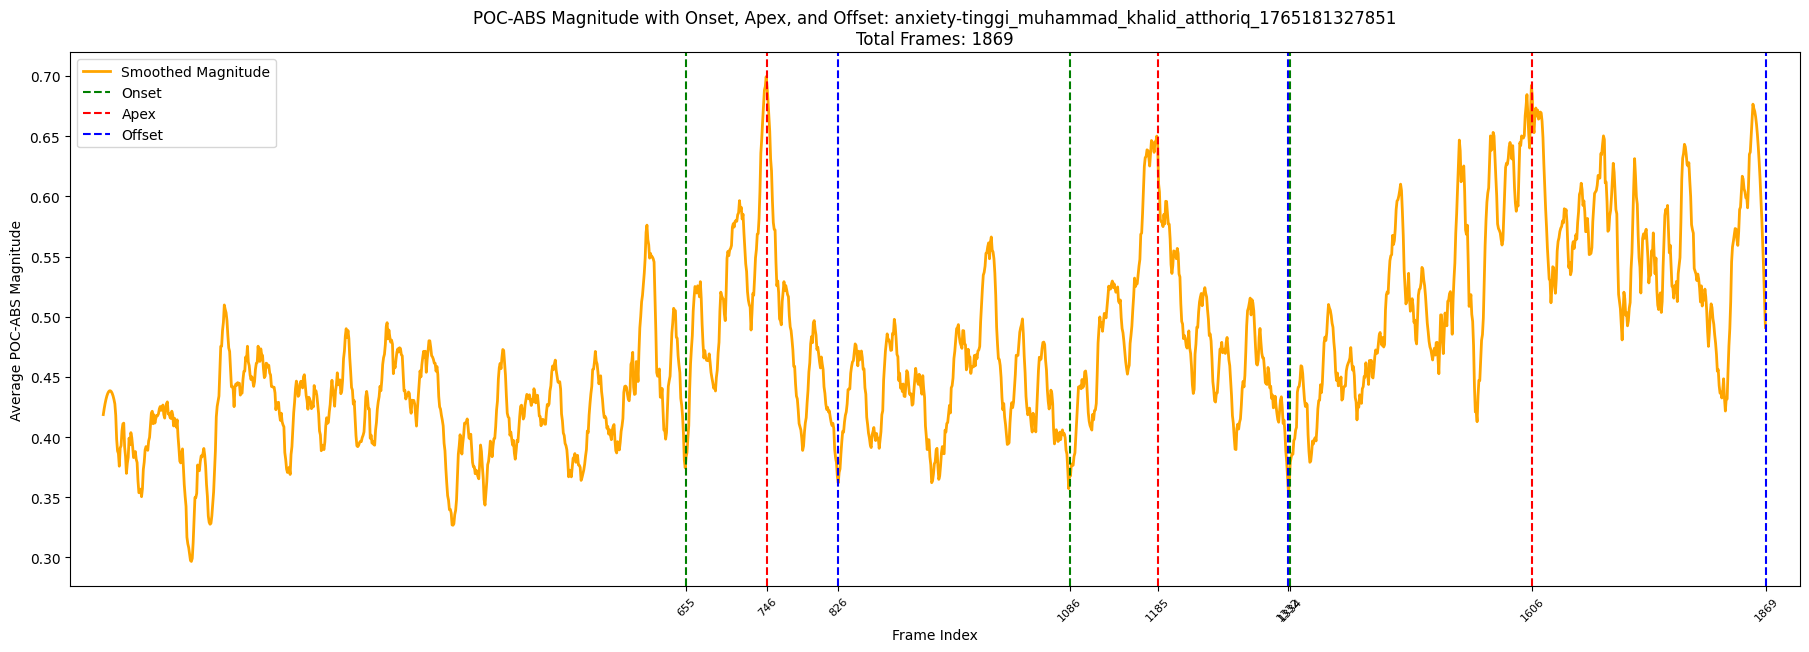

anxiety-tinggi_muhammad_khalid_atthoriq_1765181327851: 3 peak(s) → ./output/plots/anxiety-tinggi_muhammad_khalid_atthoriq_1765181327851.png
Plotting anxiety-tinggi_nova_eliza_maharani_1765181769652...
Apex: 0.5502 | Min: 0.2507 | Threshold: 0.3106
Apex: 0.5023 | Min: 0.2507 | Threshold: 0.3010
Apex: 0.5851 | Min: 0.2507 | Threshold: 0.3176


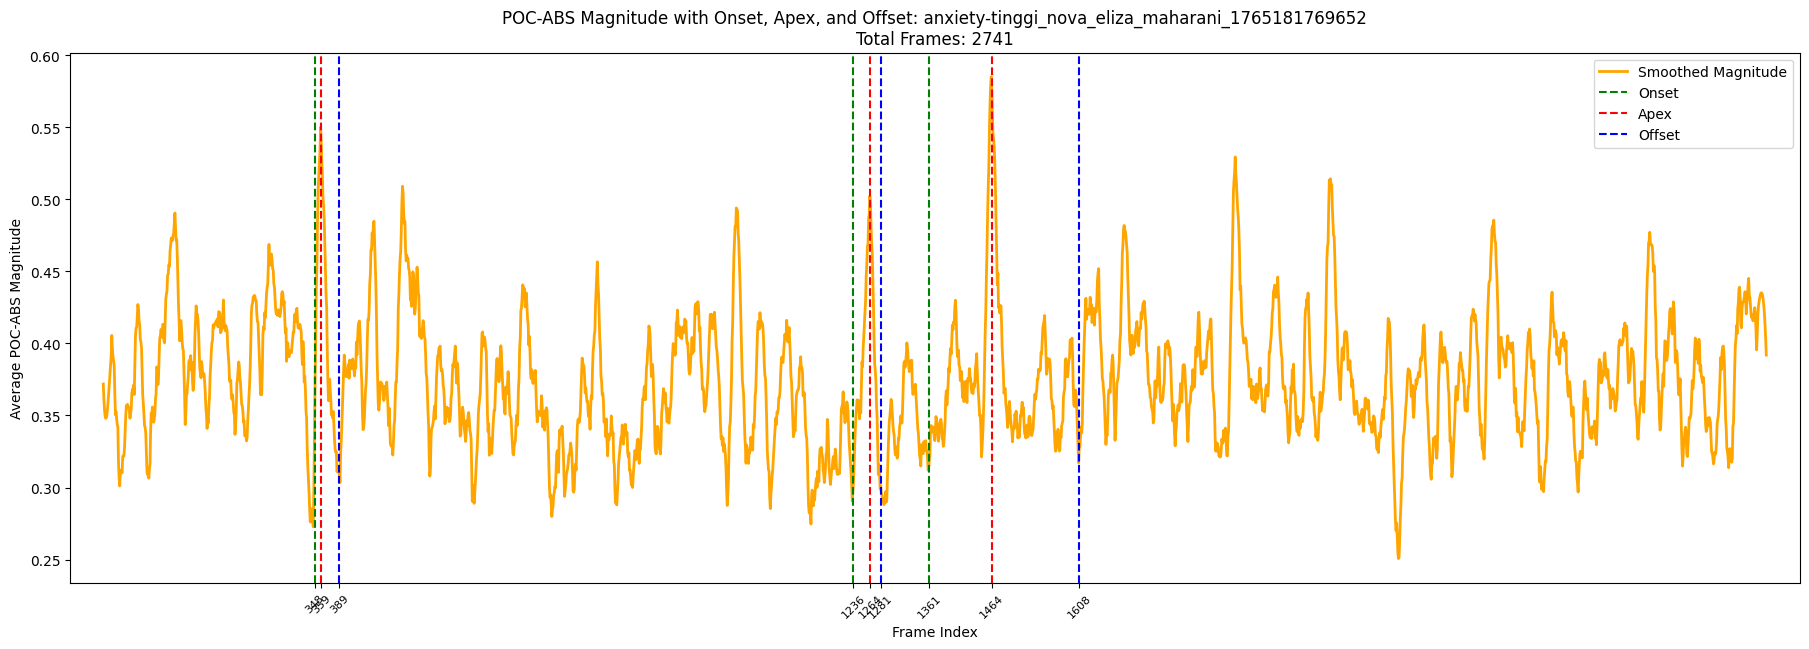

anxiety-tinggi_nova_eliza_maharani_1765181769652: 3 peak(s) → ./output/plots/anxiety-tinggi_nova_eliza_maharani_1765181769652.png

Step 3 done! 11 plot(s) saved in ./output/plots/


In [36]:
# ======================================================
# STEP 3: VISUALIZE ONSET-APEX-OFFSET
# ======================================================
def find_onset_offset(signal, apex_index, cutoff_ratio=0.35):
    apex_value = signal[apex_index]
    min_value = np.min(signal)
    threshold = min_value + (apex_value - min_value) * cutoff_ratio

    print(f"Apex: {apex_value:.4f} | Min: {min_value:.4f} | Threshold: {threshold:.4f}")

    onset_index = 0
    for i in range(apex_index, 0, -1):
        if signal[i] <= threshold:
            onset_index = i
            break

    offset_index = len(signal) - 1
    for i in range(apex_index, len(signal) - 1):
        if signal[i] <= threshold:
            offset_index = i
            break

    return onset_index, offset_index


subject_count = 0

for npy_file in sorted(os.listdir(MAGNITUDES_DIR), key=natural_sort_key):

    if not npy_file.endswith(".npy"):
        continue

    subject_name = npy_file.replace(".npy", "")
    npy_path = os.path.join(MAGNITUDES_DIR, npy_file)
    magnitude_array = np.load(npy_path)

    if len(magnitude_array) < 3:
        print(f"Skip {subject_name}: not enough data")
        continue

    print(f"Plotting {subject_name}...")

    # ---------------- Smoothing ----------------
    win_len = SAVGOL_WINDOW

    if win_len > len(magnitude_array):
        win_len = len(magnitude_array)

    if win_len % 2 == 0:
        win_len -= 1

    if win_len < SAVGOL_POLYORDER + 2:
        win_len = SAVGOL_POLYORDER + 2
        if win_len % 2 == 0:
            win_len += 1

    smooth_magnitudes = savgol_filter(
        magnitude_array, win_len, SAVGOL_POLYORDER
    )

    frame_indices = np.arange(len(magnitude_array))

    # ---------------- Peak detection ----------------
    peaks, properties = find_peaks(smooth_magnitudes, prominence=0)

    if len(peaks) > 0:
        prominences = properties["prominences"]
        top_indices = np.argsort(prominences)[::-1][:MAX_PEAKS]
        top_indices = np.sort(top_indices)
        peaks = peaks[top_indices]

    # ---------------- Onset-offset ----------------
    onset_offsets = []

    if len(peaks) > 0:
        for apex_idx in peaks:
            onset_idx, offset_idx = find_onset_offset(
                smooth_magnitudes, apex_idx, CUTOFF_RATIO
            )
            onset_offsets.append((onset_idx, apex_idx, offset_idx))

    # ---------------- Plot ----------------
    plt.figure(figsize=(18, 6))
    plt.plot(
        frame_indices,
        smooth_magnitudes,
        label="Smoothed Magnitude",
        color="orange",
        linewidth=2,
    )

    if len(onset_offsets) > 0:
        special_ticks = []

        for idx, (onset_idx, apex_idx, offset_idx) in enumerate(onset_offsets):

            # Onset
            plt.axvline(
                x=onset_idx + 1,
                color="g",
                linestyle="--",
                label="Onset" if idx == 0 else "",
            )
            special_ticks.append(onset_idx + 1)

            # Apex
            plt.axvline(
                x=apex_idx + 1,
                color="r",
                linestyle="--",
                label="Apex" if idx == 0 else "",
            )
            special_ticks.append(apex_idx + 1)

            # Offset
            plt.axvline(
                x=offset_idx + 1,
                color="b",
                linestyle="--",
                label="Offset" if idx == 0 else "",
            )
            special_ticks.append(offset_idx + 1)

        if len(special_ticks) > 0:
            special_ticks = sorted(list(set(special_ticks)))
            plt.xticks(special_ticks, special_ticks, rotation=45, fontsize=8)
            plt.gca().margins(x=0.02)
            plt.tight_layout()

    plt.title(
        f"POC-ABS Magnitude with Onset, Apex, and Offset: {subject_name}\n"
        f"Total Frames: {len(magnitude_array)}"
    )
    plt.xlabel("Frame Index")
    plt.ylabel("Average POC-ABS Magnitude")
    plt.legend()

    out_path = os.path.join(PLOTS_DIR, f"{subject_name}.png")
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"{subject_name}: {len(peaks)} peak(s) → {out_path}")
    subject_count += 1


print(f"\nStep 3 done! {subject_count} plot(s) saved in {PLOTS_DIR}/")
